In [2]:
import pandas as pd

from generate_datasets import read_redispatch_data

In [6]:
redispatch_jan_2026 = read_redispatch_data(
    file_path="../data/redispatch_data_utc_11_jan_2026.csv",
    translations_path="../data_processing/translations.json",
    timezone="UTC",
    start_date="2021-10-01",
    end_date="2026-01-10",
)

redispatch_feb_2026 = read_redispatch_data(
    file_path="../data/redispatch_data_utc_23_feb_2026.csv",
    translations_path="../data_processing/translations.json",
    timezone="UTC",
    start_date="2021-10-01",
    end_date="2026-01-10",
)

In [26]:
merge_criteria = ["begin_date", "end_date", "direction", "directing_operator", "total_load", "affected_unit", "measurement_reason"]

In [30]:
redispatch_merged = pd.merge(
    redispatch_jan_2026.drop_duplicates(subset=merge_criteria),
    redispatch_feb_2026.drop_duplicates(subset=merge_criteria),
    on=merge_criteria,
    how="outer",
    indicator=True,
)

In [31]:
redispatch_merged["_merge"].value_counts()

_merge
both          68350
right_only        7
left_only         4
Name: count, dtype: int64

In [33]:
redispatch_merged[redispatch_merged["_merge"] != "both"]

,begin_date,end_date,measurement_reason,direction,mean_load_x,max_load_x,total_load,directing_operator,requesting_operator_x,affected_unit,primary_energy_type_x,mean_load_y,max_load_y,requesting_operator_y,primary_energy_type_y,_merge
36868,2024-04-30 22:15:00,2024-05-01 22:00:00,Electricty-related redispatch,down,NaN,NaN,128.00,Amprion,NaN,WP_BEDBURG A44N,NaN,9.00,15.0,[Amprion],Renewable,right_only
36951,2024-05-01 22:00:00,2024-05-02 22:00:00,Electricty-related redispatch,down,NaN,NaN,139.00,Amprion,NaN,WP_BEDBURG A44N,NaN,8.00,16.0,[Amprion],Renewable,right_only
37073,2024-05-02 22:00:00,2024-05-03 06:30:00,Electricty-related redispatch,down,NaN,NaN,116.00,Amprion,NaN,WP_BEDBURG A44N,NaN,14.00,16.0,[Amprion],Renewable,right_only
56368,2025-06-11 04:00:00,2025-06-11 12:00:00,Probefahrt,up,NaN,NaN,2225.75,TransnetBW,NaN,Marbach GT 4 (bnBm),NaN,278.22,308.0,[TransnetBW],Conventional,right_only
56369,2025-06-11 04:00:00,2025-06-11 12:00:00,Testrun (bnBm),up,278.22,308.0,2225.75,TransnetBW,[TransnetBW],Marbach GT 4 (bnBm),Conventional,NaN,NaN,NaN,NaN,left_only
56378,2025-06-11 05:45:00,2025-06-11 10:15:00,Probefahrt,down,NaN,NaN,342.50,TransnetBW,NaN,Börse,NaN,76.11,80.0,[TransnetBW],Special,right_only
56379,2025-06-11 05:45:00,2025-06-11 10:15:00,Testrun (NetzRes),down,76.11,80.0,342.50,TransnetBW,[TransnetBW],Börse,Special,NaN,NaN,NaN,NaN,left_only
56380,2025-06-11 05:45:00,2025-06-11 10:15:00,Probefahrt,up,NaN,NaN,342.50,TransnetBW,NaN,Reservekraftwerk Marbach GT 3,NaN,76.11,80.0,[TransnetBW],Conventional,right_only
56381,2025-06-11 05:45:00,2025-06-11 10:15:00,Testrun (NetzRes),up,76.11,80.0,342.50,TransnetBW,[TransnetBW],Reservekraftwerk Marbach GT 3,Conventional,NaN,NaN,NaN,NaN,left_only
61327,2025-09-19 09:00:00,2025-09-19 13:00:00,Electricty-related redispatch,down,100.00,100.0,400.00,TenneT DE,[TenneT DE],BAG NWAK-Cluster 17 Altheim,Renewable,NaN,NaN,NaN,NaN,left_only


<Axes: xlabel='begin_date'>

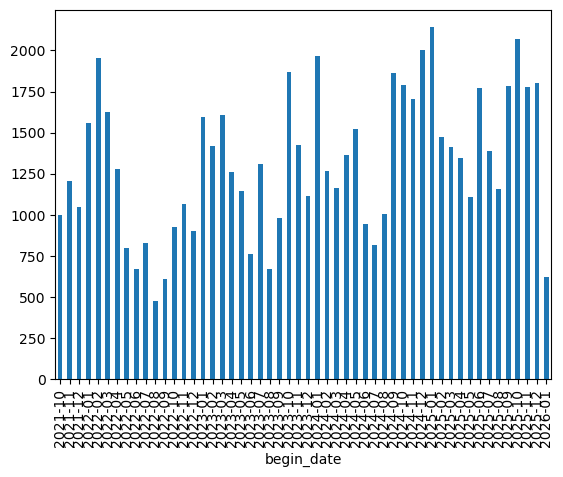

In [24]:
redispatch_jan_2026.groupby(redispatch_jan_2026["begin_date"].dt.to_period("M"))["total_load"].size().plot.bar()